In [1]:
import os
from CSTREnv import CSTREnv
from stable_baselines3 import DDPG, SAC, PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.results_plotter import load_results
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib.pyplot as plt
import numpy as np
import random
import time
import pandas as pd

def make_cstr_env(log_dir):
    os.makedirs(log_dir, exist_ok=True)
    return Monitor(CSTREnv(), log_dir)

DDPG

In [11]:
env_ddpg  = make_cstr_env("./logs/ddpg/")

n_actions = env_ddpg.action_space.shape[0]
action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.2 * np.ones(n_actions))

ddpg_agent = DDPG(
    "MlpPolicy",
    env_ddpg,
    action_noise=action_noise,
    verbose=0,
    device='cuda',
)

In [12]:
start = time.time()
ddpg_agent.learn(total_timesteps=100_000)
ddpg_agent.save("ddpg_cstr")  
end = time.time()
print(f'Time: {end-start}s')

Episode:1. state:[ -1.74162004 129.24730504], u:[-3.500000e+00 -7.818491e+04], reward:-170.0818989685343
Episode:2. state:[-1.28153824 -6.68176421], u:[-3.5000000e+00 -2.8778075e+05], reward:-2.088799994500003
Episode:3. state:[-0.76248551  8.805895  ], u:[-2.7052805e+00  4.2555269e+05], reward:-1.3568220150811396
Episode:4. state:[-0.32050904  1.91022246], u:[1.3070593e+00 3.8146938e+04], reward:-0.13921554488936363
Episode:5. state:[ 0.19450632 -4.4529086 ], u:[ 3.796587e-01 -4.254753e+04], reward:-0.23611666065750497
Episode:6. state:[-0.04307476 -0.9179881 ], u:[-3.0107372e+00  1.7398700e+05], reward:-0.010282456259226802
Episode:7. state:[ 0.09637606 -6.5655425 ], u:[4.9043393e-01 4.4242188e+04], reward:-0.44035182861290767
Episode:8. state:[0.17103167 2.13601319], u:[1.3994694e-01 7.0225688e+04], reward:-0.07487735492965271
Episode:9. state:[0.32329237 4.625162  ], u:[ 9.927583e-01 -9.367841e+04], reward:-0.3184391900891672
Episode:10. state:[-0.10657297  5.94596449], u:[ 3.45621

PPO

In [2]:
env_ppo = make_cstr_env("./logs/ppo")

ppo_agent = PPO(
    "MlpPolicy",
    env_ppo,
    verbose=0,
    device='cpu'
)

In [3]:
start = time.time()
ppo_agent.learn(total_timesteps=100_000)
ppo_agent.save("ppo_cstr")
end = time.time()
print(f'Time: {end-start}s')

Episode:1. state:[-1.02802824 58.84868363], u:[ 1.103687  -1.2630168], reward:-35.68851770897723
Episode:2. state:[-0.12549036 11.38641155], u:[-0.8822278 -0.3820991], reward:-1.3122515098532315
Episode:3. state:[-0.83240489 55.84797072], u:[0.68644744 0.52204204], reward:-31.88285623384411
Episode:4. state:[-0.67418195 37.30413234], u:[-0.37465814  0.03818393], reward:-14.370504195206914
Episode:5. state:[-0.43354897 19.36556979], u:[0.01649448 1.0289418 ], reward:-3.9382176421701183
Episode:6. state:[-0.57259331  9.70819092], u:[-2.5377305   0.28921545], reward:-1.2703528035106797
Episode:7. state:[-0.44757023 17.25761894], u:[-0.6428738   0.18913214], reward:-3.1785732270672633
Episode:8. state:[  1.09603942 -58.16279331], u:[ 0.88455653 -0.04423517], reward:-35.03040766312484
Episode:9. state:[-0.72180373 35.63863786], u:[ 0.59999204 -0.1443114 ], reward:-13.222125709513168
Episode:10. state:[-0.31279253 20.54384883], u:[ 0.9357157 -1.2087947], reward:-4.318336419033259
Episode:11.

SAC

In [4]:
env_sac  = make_cstr_env("./logs/sac/")

sac_agent = SAC(
    "MlpPolicy",
    env_sac,
    verbose=0,
    device='cuda',
)

In [5]:
start = time.time()
sac_agent.learn(total_timesteps=100_000)
sac_agent.save("sac_cstr")
end = time.time()
print(f'Time: {end-start}s')

Episode:1. state:[  0.41139603 -71.73689687], u:[-8.2329965e-01 -2.1151875e+05], reward:-51.63107042033519
Episode:2. state:[-1.48982398 70.91146689], u:[-8.603964e-01 -3.564670e+05], reward:-52.503936868339274
Episode:3. state:[ 0.38864019 13.46862122], u:[6.565237e-02 4.872450e+05], reward:-1.9650787722923695
Episode:4. state:[ 1.08134085 23.45218486], u:[-3.2849364e+00  4.7542000e+05], reward:-6.669347774914935
Episode:5. state:[  0.16431081 -11.78970371], u:[5.9496021e-01 1.4792169e+05], reward:-1.4169691787031813
Episode:6. state:[-0.03606012 -0.09799954], u:[-3.1077337e-01  2.4311925e+05], reward:-0.0013963715020288477
Episode:7. state:[-0.05727576  7.21596502], u:[-1.7904031e+00  2.0718731e+05], reward:-0.5239820238344657
Episode:8. state:[ 0.26076562 -4.69993701], u:[2.5845771e+00 1.6423288e+05], reward:-0.28889278541106717
Episode:9. state:[-0.02082546 -1.17195202], u:[-1.0083392e+00 -1.3401875e+04], reward:-0.014168415097725741
Episode:10. state:[ 0.1633559  -0.77173353], u:[

Plot

C:\Users\zhuxinji\AppData\Local\Temp\ipykernel_31716\3664615888.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


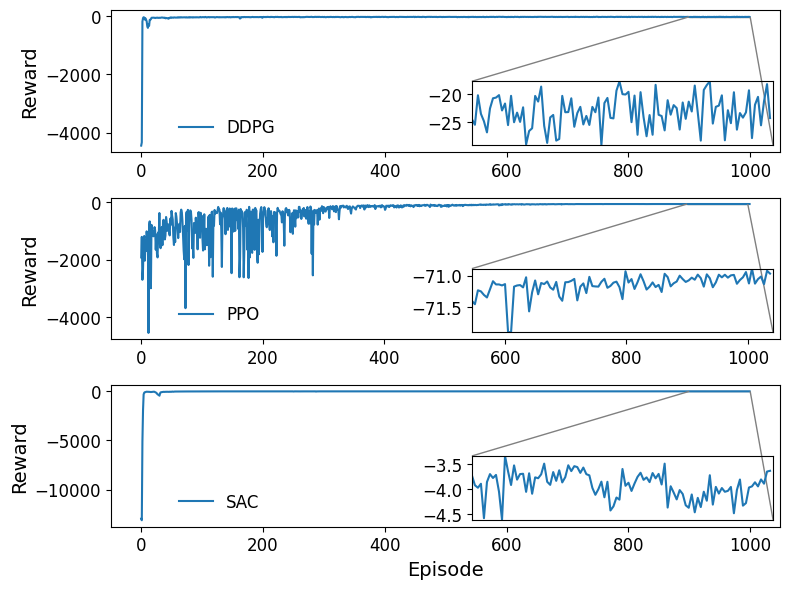

In [34]:
fig, axes = plt.subplots(3, 1, figsize=(8, 6))

logs = {
    "DDPG": "./logs/ddpg/",
    "PPO":  "./logs/ppo/",
    "SAC":  "./logs/sac/",
}

zoom = {
    "DDPG": (900, 1000),
    "PPO":  (900, 1000),
    "SAC":  (900, 1000),
}

# gobal format
label_fontsize  = 14
tick_fontsize   = 12
legend_fontsize = 12
line_width = 1.5
color = "C0"

for i, (ax, (label, log_dir)) in enumerate(zip(axes, logs.items())):
    df = load_results(log_dir)

    # -------- main plots --------
    ax.plot(df["r"], label=label,
            linewidth=line_width, color=color)

    ax.set_ylabel("Reward", fontsize=label_fontsize)
    ax.tick_params(axis="both", labelsize=tick_fontsize)

    #ax.set_xlim(0, 1000)
    
    #legend
    ax.legend(
        fontsize=legend_fontsize,
        frameon=False,
        loc="lower left",
        bbox_to_anchor=(0.08, 0.005)
    )

    if i < len(axes) - 1:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("Episode", fontsize=label_fontsize)

    # -------- inset --------
    axins = inset_axes(#
        ax,
        width="45%",
        height="45%",
        loc="lower right"
    )

    x_start, x_end = zoom[label]
    y_data = df["r"][x_start:x_end]

    axins.plot(range(x_start, x_end), y_data,
               color=color, linewidth=line_width)

    axins.set_xlim(x_start, x_end)
    axins.set_ylim(y_data.min(), y_data.max())

    axins.yaxis.set_ticks_position("left")
    axins.tick_params(axis="y", labelsize=tick_fontsize)
    axins.set_xticks([])

    mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.tight_layout()
plt.savefig("episode_reward.eps", format="eps", bbox_inches="tight")
plt.show()
